## **F1Vision** : F1 Team Detection ,Phase 3 DL Using YOLO


In [6]:
!pip install -q ultralytics roboflow

In [7]:
# Dataset

from roboflow import Roboflow
rf = Roboflow(api_key="YyHmOA9OLvKCJa0buwag")
project = rf.workspace("rama-remum").project("f1-teams-1kvx4")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [8]:
!ls /content/F1-Teams--2

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


Initially, the YOLOv8 model was trained locally on my personal computer using 50 epochs. This process took approximately 5 hours but yielded unsatisfactory results in terms of detection accuracy, precision, and recall. The limited hardware resources—particularly the absence of a compatible GPU with CUDA support—significantly slowed down training and hindered model convergence.

Consequently, the training was migrated to Roboflow, a cloud-based platform optimized for YOLO workflows. Roboflow provides automatically tuned hyperparameters (including learning rate scheduling, data augmentation policies, and dynamic batch sizing), along with access to high-performance GPUs.

During training on Roboflow, model checkpoints were utilized to preserve training progress and ensure stability. This approach led to a substantial improvement in model performance—both in speed and accuracy—while reducing total training time by over 70% compared to the local setup.

In [ ]:
# My intial model om my local pc:


#from ultralytics import YOLO

#model = YOLO("yolov8n.pt")
#model.train(
#    data=f"{dataset.location}/data.yaml",
#    epochs=50,
#    imgsz=640,
#    batch=4,
#    name="f1_test_run",
#    patience=5,
#    device="cpu",
#    verbose=False
#)

In [9]:
pip install inference-sdk

In [10]:
from inference_sdk import InferenceHTTPClient

CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="YyHmOA9OLvKCJa0buwag"
)

#result = CLIENT.infer('test.jpg', model_id="f1-teams-1kvx4/2" )

In [11]:
import cv2
import matplotlib.pyplot as plt
import json

رجاءً ارفع صورة


Saving car_000025.png to car_000025 (1).png


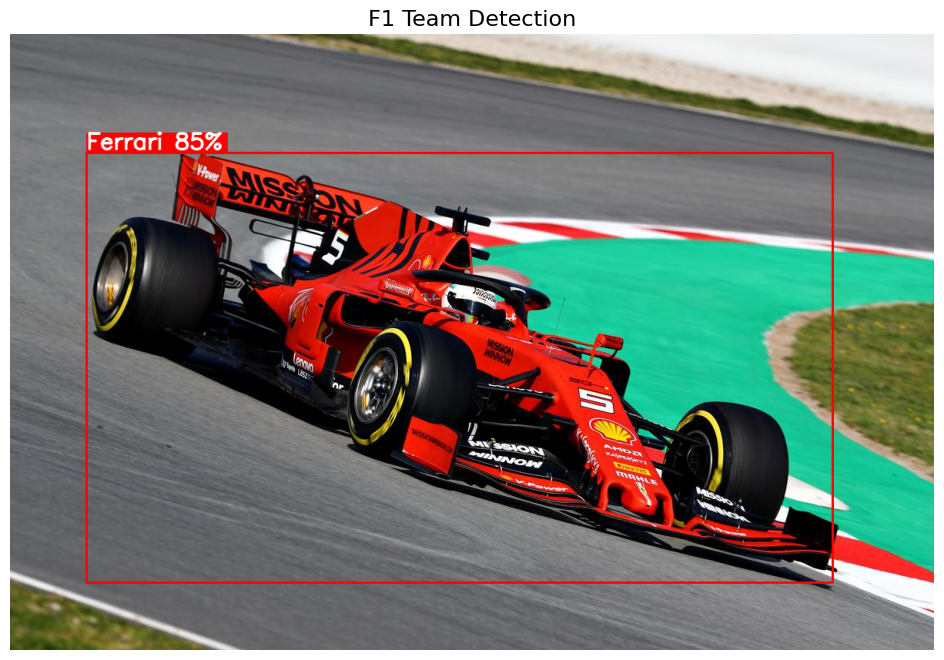


 JSON:
{
  "inference_id": "5d0b1787-1d27-4036-8c37-0534f5a53f86",
  "time": 0.05169335403479636,
  "image": {
    "width": 1200,
    "height": 800
  },
  "predictions": [
    {
      "x": 583.5,
      "y": 433.0,
      "width": 969.0,
      "height": 558.0,
      "confidence": 0.8569727540016174,
      "class": "Ferrari",
      "class_id": 2,
      "detection_id": "6ee8649f-269e-4424-addd-022404fb4efe"
    }
  ]
}


In [12]:

#رفع صورة
from google.colab import files
print("رجاءً ارفع صورة")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

#  المودل
result = CLIENT.infer(image_path, model_id="f1-teams-1kvx4/2")


img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#  تعريف ألوان الفرق الرسمية
TEAM_COLORS = {
    "Red Bull": (0, 0, 255),
    "McLaren": (255, 165, 0),
    "Ferrari": (255, 0, 0),
    "Mercedes": (0, 210, 190),
    "Alpine": (255, 100, 255),
    "Aston Martin": (3, 122, 104),
    "Haas": (200, 0, 50),
    "Racing Bulls": (0, 20, 74),
    "Williams": (0, 0, 128),
    "Kick Sauber": (50, 255, 50)
}



for pred in result.get("predictions", []):
    x1 = int(pred["x"] - pred["width"] / 2)
    y1 = int(pred["y"] - pred["height"] / 2)
    w = int(pred["width"])
    h = int(pred["height"])
    x2 = x1 + w
    y2 = y1 + h

    class_name = pred["class"]
    confidence = pred["confidence"]

    # تحديد اللون
    color = TEAM_COLORS.get(class_name, (255, 255, 255))

    font_scale = max(w * 0.001, 0.8)
    thickness = max(int(font_scale * 2), 2)


    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, thickness=thickness)


    label = f"{class_name} {int(confidence * 100)}%"


    (text_width, text_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)


    cv2.rectangle(img_rgb,
                  (x1, y1 - text_height - 5),
                  (x1 + text_width + 5, y1),
                  color,
                  -1)


    cv2.putText(
        img_rgb,
        label,
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA
    )

# 9. عرض الصورة
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(" F1 Team Detection ", fontsize=16)
plt.show()

# 10. عرض JSON
print("\n JSON:")
print(json.dumps(result, indent=2, ensure_ascii=False))

رجاءً ارفع صورة


Saving frame_002030.png to frame_002030 (1).png


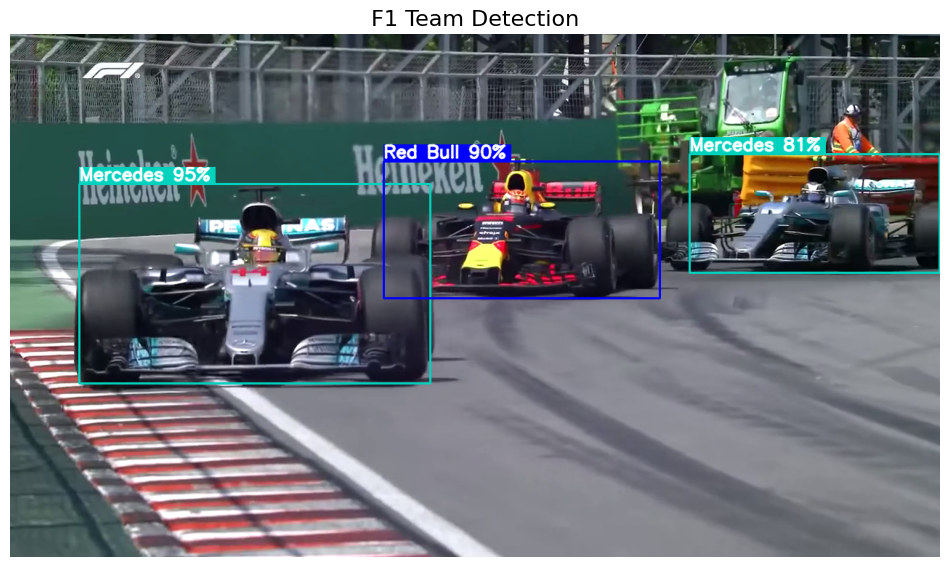


 JSON:
{
  "inference_id": "398941de-fa8a-45b4-bf8f-b6ec54a69863",
  "time": 0.04620492295362055,
  "image": {
    "width": 1280,
    "height": 720
  },
  "predictions": [
    {
      "x": 336.5,
      "y": 344.0,
      "width": 483.0,
      "height": 274.0,
      "confidence": 0.9535906314849854,
      "class": "Mercedes",
      "class_id": 6,
      "detection_id": "1d6f08f1-8cfa-4a16-b36d-f82955aa2698"
    },
    {
      "x": 704.0,
      "y": 270.0,
      "width": 380.0,
      "height": 188.0,
      "confidence": 0.9096189737319946,
      "class": "Red Bull",
      "class_id": 8,
      "detection_id": "56dafa8d-2828-4d28-8167-b2ac40344707"
    },
    {
      "x": 1107.0,
      "y": 247.5,
      "width": 344.0,
      "height": 163.0,
      "confidence": 0.8190696835517883,
      "class": "Mercedes",
      "class_id": 6,
      "detection_id": "d0f274b3-93d1-4d2d-b371-eb5a7b14647d"
    }
  ]
}


In [13]:
# try multi car detection

from google.colab import files
print("رجاءً ارفع صورة")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

result = CLIENT.infer(image_path, model_id="f1-teams-1kvx4/2")


img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



for pred in result.get("predictions", []):
    x1 = int(pred["x"] - pred["width"] / 2)
    y1 = int(pred["y"] - pred["height"] / 2)
    w = int(pred["width"])
    h = int(pred["height"])
    x2 = x1 + w
    y2 = y1 + h

    class_name = pred["class"]
    confidence = pred["confidence"]


    color = TEAM_COLORS.get(class_name, (255, 255, 255))

    font_scale = max(w * 0.001, 0.8)
    thickness = max(int(font_scale * 2), 2)


    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, thickness=thickness)


    label = f"{class_name} {int(confidence * 100)}%"


    (text_width, text_height), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)


    cv2.rectangle(img_rgb,
                  (x1, y1 - text_height - 5),
                  (x1 + text_width + 5, y1),
                  color,
                  -1)


    cv2.putText(
        img_rgb,
        label,
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA
    )


plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(" F1 Team Detection ", fontsize=16)
plt.show()


print("\n JSON:")
print(json.dumps(result, indent=2, ensure_ascii=False))

## Note : The model evaluation results are saved in a separate folder, providing a detailed breakdown of precision, recall, dataset analysis, heatmap and the confusion matrix.